# 3단계 — ML 베이스라인 모델 (TF-IDF + Logistic Regression)

GPU 없이도 수 초 안에 학습·추론이 가능한 경량 모델입니다.

파이프라인:
```
텍스트 → TF-IDF 벡터화 → Logistic Regression → 클래스 확률
```

In [16]:
import sys
sys.path.insert(0, '..')

from src.data.preprocessor import Preprocessor
from src.data.loader import load_datasets
from src.models.ml_model import MLSpamClassifier

print('모듈 로드 완료')

모듈 로드 완료


## 데이터 로드 & 전처리

In [17]:
from src.data.preprocessor import Preprocessor
from src.data.loader import load_datasets

pre = Preprocessor(use_konlpy=False)

DATA_PATHS = [
    "../data/translated_en_to_ko.csv",  
]

data = load_datasets(
    csv_paths=DATA_PATHS,
    preprocessor=pre,
    train_ratio=0.8,
    val_ratio=0.1,
    random_state=42,
)

[데이터] 1개 CSV 병합 → 총 1750개
  스팸: 890개 | 정상: 860개
[전처리] 텍스트 정제 중...
[분리] train=1400 | val=175 | test=175


## 모델 학습

In [18]:
model = MLSpamClassifier(
    max_features=50_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    C=0.3,
    class_weight='balanced',
    spam_threshold=0.7,
)

model.fit(data.X_train, data.y_train, data.X_val, data.y_val)

[ML] 학습 시작...
[ML] 학습 완료
[ML] Validation 결과:
              precision    recall  f1-score   support

         ham       0.90      0.94      0.92        86
        spam       0.94      0.90      0.92        89

    accuracy                           0.92       175
   macro avg       0.92      0.92      0.92       175
weighted avg       0.92      0.92      0.92       175



c:\Users\ion01\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


## Test 세트 최종 평가

In [19]:
import time
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

t0 = time.perf_counter()
results = model.predict(data.X_test)
elapsed_ms = (time.perf_counter() - t0) * 1000

y_pred = [1 if r.label == 'spam' else 0 for r in results]

print(classification_report(data.y_test, y_pred, target_names=['ham', 'spam']))
print(f'추론 시간: {elapsed_ms:.1f}ms | 평균 {elapsed_ms/len(data.X_test):.2f}ms/건')

              precision    recall  f1-score   support

         ham       0.62      1.00      0.77        86
        spam       1.00      0.42      0.59        89

    accuracy                           0.70       175
   macro avg       0.81      0.71      0.68       175
weighted avg       0.81      0.70      0.68       175

추론 시간: 13.1ms | 평균 0.07ms/건


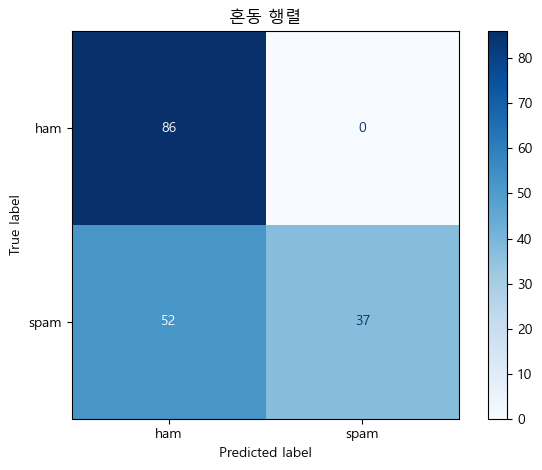

In [20]:
cm = confusion_matrix(data.y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['ham', 'spam'])
disp.plot(cmap='Blues')
plt.title('혼동 행렬')
plt.tight_layout()
plt.show()

## 오버피팅 진단

Train 정확도와 Test 정확도를 비교합니다.  
- **Train ≈ Test** → 정상  
- **Train >> Test** → 오버피팅  

### 주요 대응 방법
1. **데이터 확충** — 다양한 출처의 데이터 추가 (현재 적용됨)  
2. **정규화 강화** —  값 낮추기 (L2 페널티 증가)  
3. **K-Fold 교차 검증** — 분산 확인  
4. **특성 수 축소** —  줄이기

In [21]:
from sklearn.metrics import accuracy_score, f1_score

# Train 성능
y_train_pred = [1 if r.label == "spam" else 0 for r in model.predict(data.X_train)]
train_acc = accuracy_score(data.y_train, y_train_pred)
train_f1  = f1_score(data.y_train, y_train_pred)

# Test 성능
y_test_pred = [1 if r.label == "spam" else 0 for r in model.predict(data.X_test)]
test_acc = accuracy_score(data.y_test, y_test_pred)
test_f1  = f1_score(data.y_test, y_test_pred)

gap_acc = train_acc - test_acc
gap_f1  = train_f1  - test_f1

print(f"Train  Accuracy={train_acc:.4f}  F1={train_f1:.4f}")
print(f"Test   Accuracy={test_acc:.4f}  F1={test_f1:.4f}")
print(f"GAP    Accuracy={gap_acc:+.4f}  F1={gap_f1:+.4f}")

if gap_acc > 0.05 or gap_f1 > 0.05:
    print("⚠️  오버피팅 의심 — C 값을 낮추거나 데이터를 늘리세요")
else:
    print("✅  일반화 양호")

Train  Accuracy=0.7150  F1=0.6107
Test   Accuracy=0.7029  F1=0.5873
GAP    Accuracy=+0.0121  F1=+0.0234
✅  일반화 양호


## K-Fold 교차 검증

로 데이터 전체를 사용해 분산을 확인합니다.  
학습 데이터가 적을 때 특히 유용합니다.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import numpy as np

all_X = data.X_train + data.X_val + data.X_test
all_y = data.y_train + data.y_val + data.y_test

pipeline_cv = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50_000, ngram_range=(1,2), sublinear_tf=True)),
    ("clf",   LogisticRegression(C=0.3, class_weight="balanced", max_iter=1000)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline_cv, all_X, all_y, cv=cv, scoring="f1", n_jobs=-1)

print(f"5-Fold CV F1: {scores}")
print(f"평균 F1: {scores.mean():.4f} ± {scores.std():.4f}")

# 표준편차가 크면 오버피팅 또는 데이터 불균형 신호
if scores.std() > 0.03:
    print("⚠️  Fold 간 편차 큼 — 데이터 다양성 부족 또는 오버피팅")
else:
    print("✅  안정적인 교차 검증 결과")

5-Fold CV F1: [0.95530726 0.94915254 0.95798319 0.96571429 0.95264624]
평균 F1: 0.9562 ± 0.0056
✅  안정적인 교차 검증 결과


## 학습 곡선 (Learning Curve)

학습 데이터 양을 늘렸을 때 Train F1과 Val F1이 어떻게 변하는지 확인합니다.

- **두 선이 수렴** → 데이터를 더 늘리면 성능 향상 가능  
- **Train만 높고 Val은 낮은 채 고정** → 모델 복잡도 문제 (C 값 낮추기)  
- **두 선 모두 낮음** → 데이터 부족 또는 특성 부족

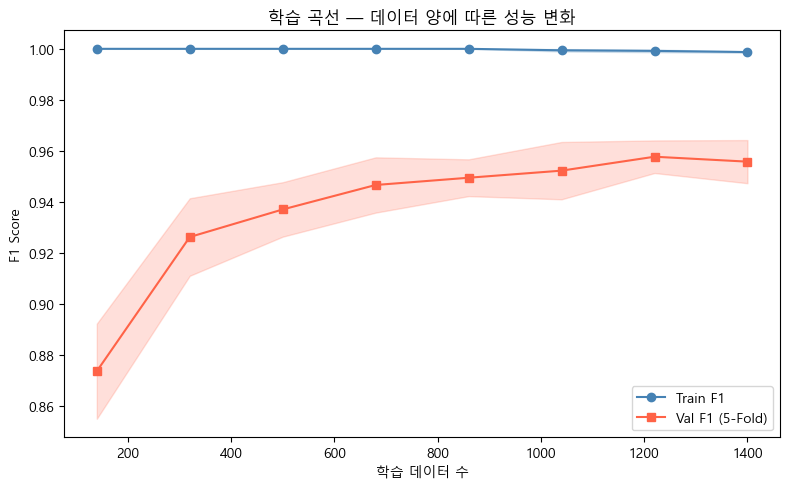

전체 데이터 사용 시 Train-Val 갭: 0.0430
✅  일반화 양호


In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

all_X = data.X_train + data.X_val + data.X_test
all_y = data.y_train + data.y_val + data.y_test

pipe_lc = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=50_000, ngram_range=(1,2), sublinear_tf=True)),
    ('clf',   LogisticRegression(C=0.3, class_weight='balanced', max_iter=1000)),
])

train_sizes, train_scores, val_scores = learning_curve(
    pipe_lc, all_X, all_y,
    cv=5, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(1), 'o-', label='Train F1', color='steelblue')
ax.fill_between(train_sizes,
    train_scores.mean(1) - train_scores.std(1),
    train_scores.mean(1) + train_scores.std(1), alpha=0.2, color='steelblue')
ax.plot(train_sizes, val_scores.mean(1), 's-', label='Val F1 (5-Fold)', color='tomato')
ax.fill_between(train_sizes,
    val_scores.mean(1) - val_scores.std(1),
    val_scores.mean(1) + val_scores.std(1), alpha=0.2, color='tomato')
ax.set_xlabel('학습 데이터 수')
ax.set_ylabel('F1 Score')
ax.set_title('학습 곡선 — 데이터 양에 따른 성능 변화')
ax.legend()
plt.tight_layout()
plt.show()

gap = train_scores.mean(1)[-1] - val_scores.mean(1)[-1]
print(f'전체 데이터 사용 시 Train-Val 갭: {gap:.4f}')
if gap > 0.05:
    print('⚠️  오버피팅 — C 값을 낮추거나 max_features를 줄이세요')
else:
    print('✅  일반화 양호')

## 중요 특성 (TF-IDF 가중치 상위 단어)

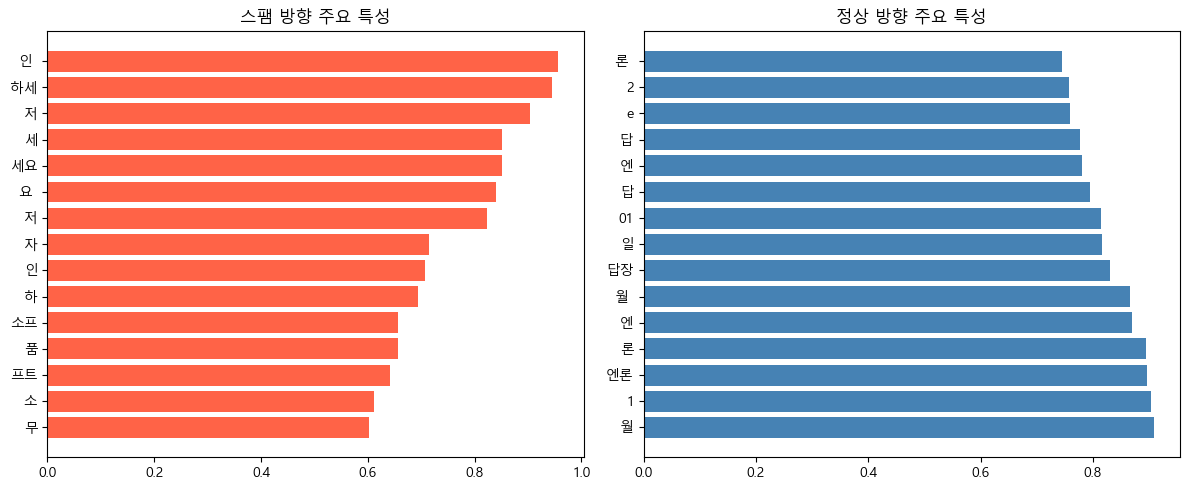

In [9]:
import numpy as np

tfidf  = model._pipeline.named_steps['tfidf']
clf    = model._pipeline.named_steps['clf']
names  = tfidf.get_feature_names_out()
coefs  = clf.coef_[0]  # ham=음수, spam=양수

top_n = 15
spam_idx = np.argsort(coefs)[-top_n:][::-1]
ham_idx  = np.argsort(coefs)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].barh(names[spam_idx][::-1], coefs[spam_idx][::-1], color='tomato')
axes[0].set_title('스팸 방향 주요 특성')

axes[1].barh(names[ham_idx], np.abs(coefs[ham_idx]), color='steelblue')
axes[1].set_title('정상 방향 주요 특성')

plt.tight_layout()
plt.show()

## 모델 저장

In [10]:
import os
os.makedirs('../artifacts', exist_ok=True)
model.save('../artifacts/ml_model.joblib')
print('저장 완료!')

[ML] 모델 저장: ../artifacts/ml_model.joblib
저장 완료!


## 직접 테스트

In [11]:
test_cases = [
    ('(광고)영상 편집 스킬을 향상하는 방법을 알아보세요', "Adobe Creative Cloud 프레임 너머로 확장 Adobe Premiere의 '생성형 확장' 기능을 이용해 보세요. 재촬영 없이도 영상 클립에 필요한 프레임을 자유롭게 추가할 수 있습니다. 클릭 후 드래그만 하면 됩니다. 새로운 영상과 오디오를 간편하게 생성해 나만의 스타일로 크리에이티브 비전을 완성하세요. Creative Cloud 모든 앱에서 이용 가능합니다."),
    ('내일 회의 자료 공유드립니다', '안녕하세요. 내일 오전 10시 회의 자료 첨부드립니다. 검토 부탁드립니다.'),
    ('당신이 선택되었습니다!', '축하합니다! 1등 당첨! 지금 바로 수령하세요. 010-0000-0000'),
]

for subject, body in test_cases:
    text = pre.preprocess(subject, body)
    result = model.predict_single(text)
    print(f'[{result.label.upper():4s}] 신뢰도={result.confidence:.2%} | 제목: {subject}')

[HAM ] 신뢰도=38.27% | 제목: (광고)영상 편집 스킬을 향상하는 방법을 알아보세요
[HAM ] 신뢰도=50.35% | 제목: 내일 회의 자료 공유드립니다
[HAM ] 신뢰도=33.76% | 제목: 당신이 선택되었습니다!


---

## 하이퍼파라미터 튜닝 (RandomizedSearchCV)

`C`, `max_features`, `ngram_range`, `min_df` 조합을 무작위 탐색합니다.

- **n_iter=20** : 20가지 조합 탐색 (늘릴수록 정확하지만 느림)
- **cv=3** : 3-fold 교차 검증
- **scoring="f1"** : 스팸(1) 기준 F1으로 최적화

In [12]:
from scipy.stats import loguniform
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

# train + val 합쳐서 탐색
X_search = data.X_train + data.X_val
y_search = data.y_train + data.y_val

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, analyzer='char_wb')),
    ('clf',   LogisticRegression(class_weight='balanced', solver='lbfgs',
                                  n_jobs=-1, max_iter=1000)),
])

param_dist = {
    'tfidf__max_features': [10_000, 30_000, 50_000, 80_000],
    'tfidf__ngram_range':  [(1, 1), (1, 2), (1, 3), (2, 3)],
    'tfidf__min_df':       [1, 2, 3, 5],
    'clf__C':              loguniform(1e-2, 1e2),
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

search.fit(X_search, y_search)

print('\n최적 파라미터:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nCV F1: {search.best_score_:.4f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits

최적 파라미터:
  clf__C: 2.801635158716261
  tfidf__max_features: 30000
  tfidf__min_df: 5
  tfidf__ngram_range: (2, 3)

CV F1: 0.9572


c:\Users\ion01\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [13]:
# 최적 파라미터로 재학습 & 최종 평가
best = search.best_params_

tuned_model = MLSpamClassifier(
    max_features=best['tfidf__max_features'],
    ngram_range=best['tfidf__ngram_range'],
    min_df=best['tfidf__min_df'],
    C=best['clf__C'],
    class_weight='balanced',
    spam_threshold=0.7,
)

tuned_model.fit(data.X_train, data.y_train, data.X_val, data.y_val)

results_tuned = tuned_model.predict(data.X_test)
y_pred_tuned  = [1 if r.label == 'spam' else 0 for r in results_tuned]

print('=== 튜닝 후 Test 결과 ===')
print(classification_report(data.y_test, y_pred_tuned, target_names=['ham', 'spam']))

[ML] 학습 시작...
[ML] 학습 완료
[ML] Validation 결과:
              precision    recall  f1-score   support

         ham       0.91      0.97      0.94        86
        spam       0.96      0.91      0.94        89

    accuracy                           0.94       175
   macro avg       0.94      0.94      0.94       175
weighted avg       0.94      0.94      0.94       175

=== 튜닝 후 Test 결과 ===
              precision    recall  f1-score   support

         ham       0.87      0.98      0.92        86
        spam       0.97      0.85      0.91        89

    accuracy                           0.91       175
   macro avg       0.92      0.92      0.91       175
weighted avg       0.92      0.91      0.91       175



c:\Users\ion01\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


---

## 임계값 최적화 (ROC 커브)

현재 `SPAM_THRESHOLD=0.7` 고정값 대신, ROC 커브로 **FP(정상→스팸 오분류)를 억제하면서 Recall을 최대화하는 최적 임계값**을 찾습니다.

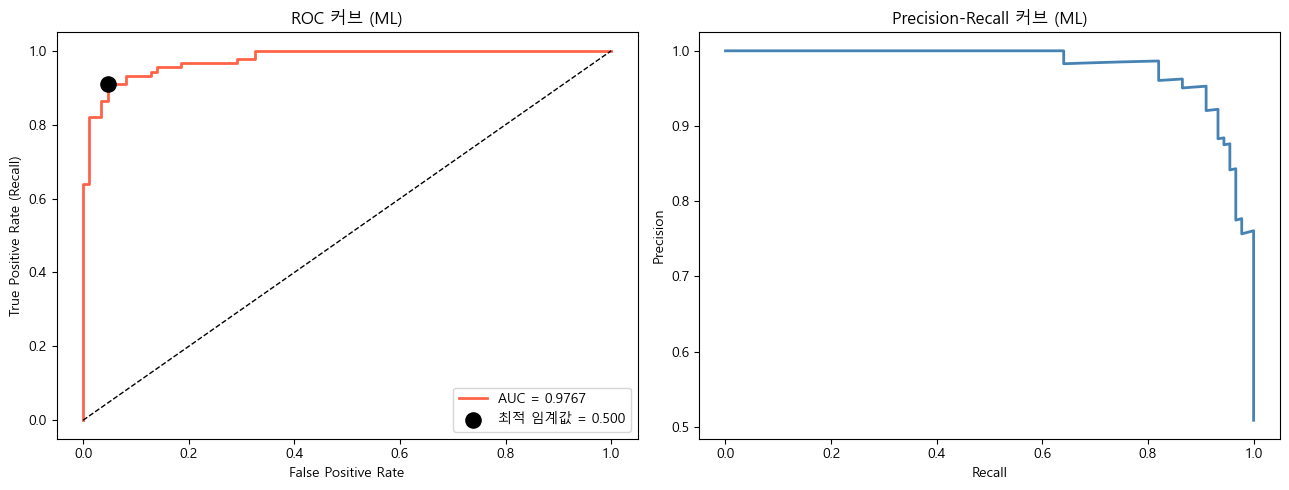


현재 임계값  : 0.700
최적 임계값  : 0.500  (Youden J 기준)
ROC AUC     : 0.9767


In [14]:
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# val 세트 스팸 확률 추출
spam_probs_val = [proba[1] for proba in model.predict_proba(data.X_val)]
spam_probs_test = [proba[1] for proba in model.predict_proba(data.X_test)]

# ── ROC 커브 ──────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(data.y_val, spam_probs_val, pos_label=1)
roc_auc = auc(fpr, tpr)

# Youden's J 기준 최적 임계값 (Sensitivity + Specificity 최대화)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

# ── Precision-Recall 커브 ─────────────────────────────────────
precision, recall, pr_thresholds = precision_recall_curve(data.y_val, spam_probs_val)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC 커브
axes[0].plot(fpr, tpr, color='tomato', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0].scatter(fpr[best_idx], tpr[best_idx], s=120, zorder=5,
                color='black', label=f'최적 임계값 = {best_threshold:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC 커브 (ML)')
axes[0].legend()

# Precision-Recall 커브
axes[1].plot(recall, precision, color='steelblue', lw=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall 커브 (ML)')

plt.tight_layout()
plt.show()

print(f'\n현재 임계값  : 0.700')
print(f'최적 임계값  : {best_threshold:.3f}  (Youden J 기준)')
print(f'ROC AUC     : {roc_auc:.4f}')

In [15]:
# 최적 임계값으로 test 세트 재평가
model.SPAM_THRESHOLD = best_threshold

results_opt = model.predict(data.X_test)
y_pred_opt  = [1 if r.label == 'spam' else 0 for r in results_opt]

print(f'=== 임계값 {best_threshold:.3f} 적용 후 Test 결과 ===')
print(classification_report(data.y_test, y_pred_opt, target_names=['ham', 'spam']))

=== 임계값 0.500 적용 후 Test 결과 ===
              precision    recall  f1-score   support

         ham       0.92      0.88      0.90        86
        spam       0.89      0.92      0.91        89

    accuracy                           0.90       175
   macro avg       0.90      0.90      0.90       175
weighted avg       0.90      0.90      0.90       175

